In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Install XG BOOST
!pip install xgboost -q
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)



In [2]:
# 2, Load Dataset
df = pd.read_csv("/content/heart_2022_with_nans.csv")

print(df.shape)
df.head()

(445132, 40)


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [3]:

# 3, Dataset Overview

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Records")
display(df.head())

print("\nDataset Information")
df.info()

Dataset Shape:
(445132, 40)

First 5 Records


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      445132 non-null  object 
 1   Sex                        445132 non-null  object 
 2   GeneralHealth              443934 non-null  object 
 3   PhysicalHealthDays         434205 non-null  float64
 4   MentalHealthDays           436065 non-null  float64
 5   LastCheckupTime            436824 non-null  object 
 6   PhysicalActivities         444039 non-null  object 
 7   SleepHours                 439679 non-null  float64
 8   RemovedTeeth               433772 non-null  object 
 9   HadHeartAttack             442067 non-null  object 
 10  HadAngina                  440727 non-null  object 
 11  HadStroke                  443575 non-null  object 
 12  HadAsthma                  443359 non-null  object 
 13  HadSkinC

In [5]:
# 4, Identify Missing Values
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

,0
TetanusLast10Tdap,82516
PneumoVaxEver,77040
HIVTesting,66127
ChestScan,56046
CovidPos,50764
HighRiskLastYear,50623
BMI,48806
FluVaxLast12,47121
AlcoholDrinkers,46574
WeightInKilograms,42078


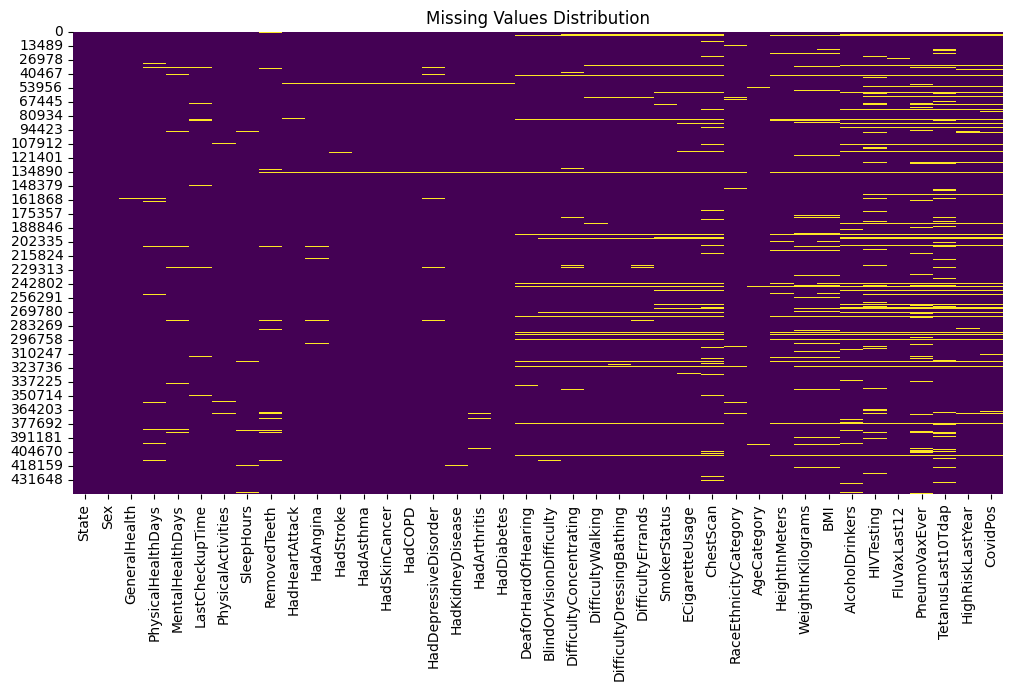

In [6]:
# 5, Visualize Missing Values

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Distribution")

plt.show()

In [18]:
# 7, Data Cleaning (Handle Missing Values)

categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

df[categorical_columns] = df[categorical_columns].apply(
    lambda x: x.fillna(x.mode()[0])
)

df[numerical_columns] = df[numerical_columns].apply(
    lambda x: x.fillna(x.median())
)

print("Remaining Missing Values:", df.isnull().sum().sum())

Remaining Missing Values: 0


In [7]:
# Check Duplicate Rows
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 157


In [10]:
# Remove Duplicates
df.drop_duplicates(inplace=True)

In [11]:
# Check Number of rows after duplicate
df.shape

(444975, 40)

In [12]:
print('Class distribution of HadHeartAttack (Counts):')
print(df['HadHeartAttack'].value_counts())

print('\nClass distribution of HadHeartAttack (Percentages):')
print(df['HadHeartAttack'].value_counts(normalize=True) * 100)

Class distribution of HadHeartAttack (Counts):
HadHeartAttack
No     416807
Yes     25108
Name: count, dtype: int64

Class distribution of HadHeartAttack (Percentages):
HadHeartAttack
No     94.318364
Yes     5.681636
Name: proportion, dtype: float64


In [16]:
 #Statistical Summaries
 df[["PhysicalHealthDays", "MentalHealthDays", "SleepHours", "HeightInMeters", "WeightInKilograms", 'BMI']].describe()


,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI
count,434053.000000,435913.000000,439527.000000,416470.000000,403044.000000,396316.000000
mean,4.349372,4.384164,7.022909,1.702690,83.074632,28.529907
std,8.689968,8.388541,1.502618,0.107178,21.448241,6.554917
min,0.000000,0.000000,1.000000,0.910000,22.680000,12.020000
25%,0.000000,0.000000,6.000000,1.630000,68.040000,24.130000
50%,0.000000,0.000000,7.000000,1.700000,80.740000,27.440000
75%,3.000000,5.000000,8.000000,1.780000,95.250000,31.750000
max,30.000000,30.000000,24.000000,2.410000,292.570000,99.640000


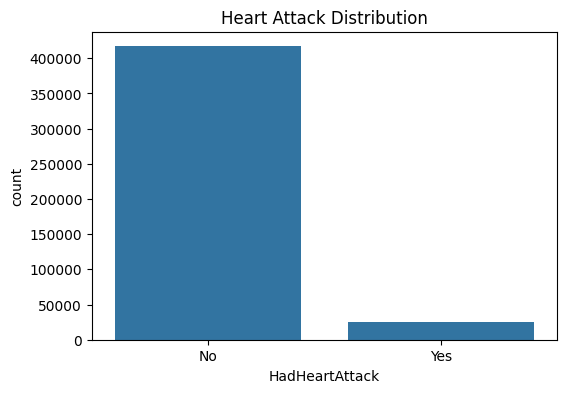

In [14]:
# 6, Target Vaiable (Heart Attack Distribution)

plt.figure(figsize=(6,4))
sns.countplot(
    x="HadHeartAttack",
    data=df
)
plt.title("Heart Attack Distribution")

plt.show()

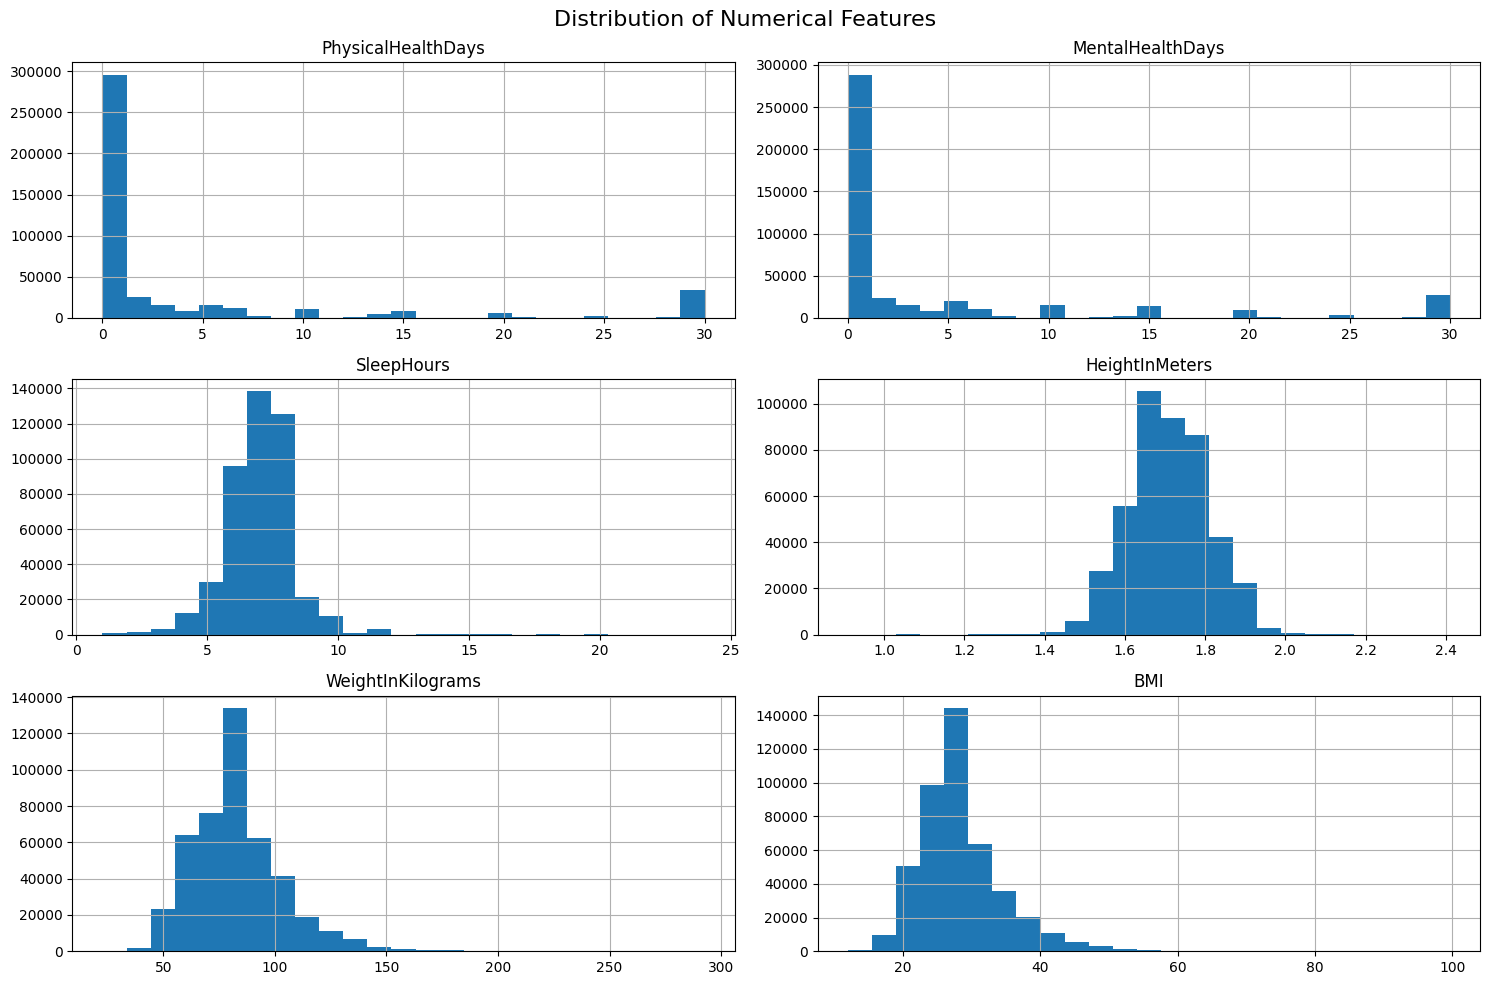

In [ ]:
numerical_features = [
    "PhysicalHealthDays",
    "MentalHealthDays",
    "SleepHours",
    "HeightInMeters",
    "WeightInKilograms",
    "BMI"
]

df[numerical_features].hist(
    figsize=(15,10),
    bins=25
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

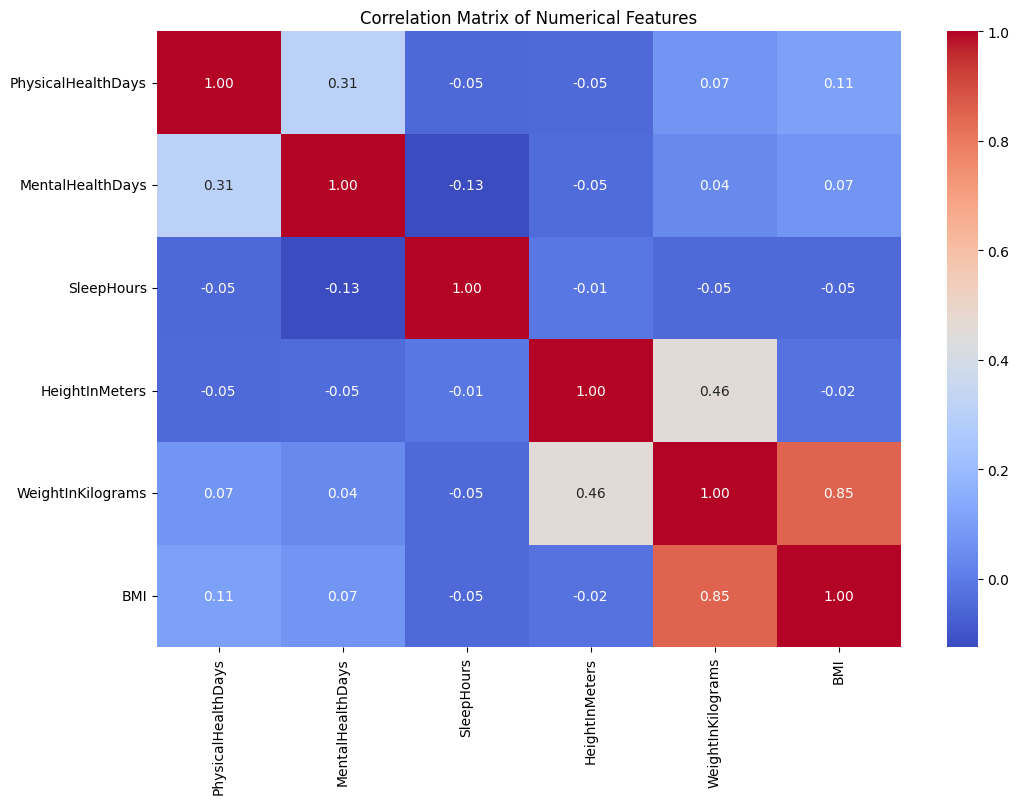

In [ ]:
# Correlation Matrix
plt.figure(figsize=(12,8))

correlation_matrix = df[
    [
        "PhysicalHealthDays",
        "MentalHealthDays",
        "SleepHours",
        "HeightInMeters",
        "WeightInKilograms",
        "BMI"
    ]
].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Numerical Features"
)

plt.show()

In [19]:
# 8, Feature Engineering
#BMI Category
df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0,18.5,25,30,100],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ]
)
# Sleep Catagory
df["Sleep_Category"] = pd.cut(
    df["SleepHours"],
    bins=[0,6,8,24],
    labels=[
        "Low Sleep",
        "Normal Sleep",
        "High Sleep"
    ]
)

In [20]:
# 9, Encoding Catagorical Variables

df = pd.get_dummies(
    df,
    drop_first=True
)

In [21]:
# 10, Identify Feature and Target

target_column = "HadHeartAttack_Yes"

X = df.drop(
    target_column,
    axis=1
)

y = df[target_column]

In [22]:
# 11, Train-Test-Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(355980, 126)
(88995, 126)


In [26]:
# 12, Feature Scalling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [27]:
# 13, Handle Class Imbalance

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
HadHeartAttack_Yes
False    335894
True     335894
Name: count, dtype: int64


Model Training

In [25]:
# 14, Logistics Regression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_lr = lr_model.predict(
    X_test_scaled
)

lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]

lr_results = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr),
    "ROC-AUC": roc_auc_score(y_test, lr_prob)
}

print(lr_results)

{'Accuracy': 0.8198101016911062, 'Precision': 0.20484510665666203, 'Recall': 0.7610513739545998, 'F1 Score': 0.32280405405405405, 'ROC-AUC': np.float64(0.8784747892856632)}


In [28]:
# 15, Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_rf = rf_model.predict(
    X_test_scaled
)

rf_prob = rf_model.predict_proba(X_test_scaled)[:,1]

rf_results = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, rf_prob)
}

print(rf_results)

{'Accuracy': 0.946120568571268, 'Precision': 0.5636567582725743, 'Recall': 0.2001194743130227, 'F1 Score': 0.29537105069801617, 'ROC-AUC': np.float64(0.8744554529420223)}


In [29]:
# 16, Gradient Boosting

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_gb = gb_model.predict(
    X_test_scaled
)

gb_prob = gb_model.predict_proba(X_test_scaled)[:,1]

gb_results = {
    "Accuracy": accuracy_score(y_test, y_pred_gb),
    "Precision": precision_score(y_test, y_pred_gb),
    "Recall": recall_score(y_test, y_pred_gb),
    "F1 Score": f1_score(y_test, y_pred_gb),
    "ROC-AUC": roc_auc_score(y_test, gb_prob)
}

print(gb_results)

{'Accuracy': 0.9445025001404573, 'Precision': 0.511921861534042, 'Recall': 0.3548387096774194, 'F1 Score': 0.4191461836998706, 'ROC-AUC': np.float64(0.8745230120168672)}


In [30]:
# 17, XGBOOST

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_xgb = xgb_model.predict(
    X_test_scaled
)

xgb_prob = xgb_model.predict_proba(X_test_scaled)[:,1]

xgb_results = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, xgb_prob)
}

print("\nXGBoost Results")
print(xgb_results)


XGBoost Results
{'Accuracy': 0.9470307320635991, 'Precision': 0.5639004149377593, 'Recall': 0.27060931899641577, 'F1 Score': 0.36571582346609255, 'ROC-AUC': np.float64(0.8843971049786947)}


In [31]:
# 17, Model Comparison
comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "Accuracy": [
        lr_results["Accuracy"],
        rf_results["Accuracy"],
        gb_results["Accuracy"],
        xgb_results["Accuracy"]
    ],

    "Precision": [
        lr_results["Precision"],
        rf_results["Precision"],
        gb_results["Precision"],
        xgb_results["Precision"]
    ],

    "Recall": [
        lr_results["Recall"],
        rf_results["Recall"],
        gb_results["Recall"],
        xgb_results["Recall"]
    ],

    "F1 Score": [
        lr_results["F1 Score"],
        rf_results["F1 Score"],
        gb_results["F1 Score"],
        xgb_results["F1 Score"]
    ],

    "ROC-AUC": [
        lr_results["ROC-AUC"],
        rf_results["ROC-AUC"],
        gb_results["ROC-AUC"],
        xgb_results["ROC-AUC"]
    ]

})

comparison_df = comparison_df.round(4)

comparison_df = comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

print("\nModel Performance Comparison")
print("=" * 100)
print(comparison_df.to_string(index=False))


Model Performance Comparison
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
            XGBoost    0.9470     0.5639  0.2706    0.3657   0.8844
Logistic Regression    0.8198     0.2048  0.7611    0.3228   0.8785
      Random Forest    0.9461     0.5637  0.2001    0.2954   0.8745
  Gradient Boosting    0.9445     0.5119  0.3548    0.4191   0.8745


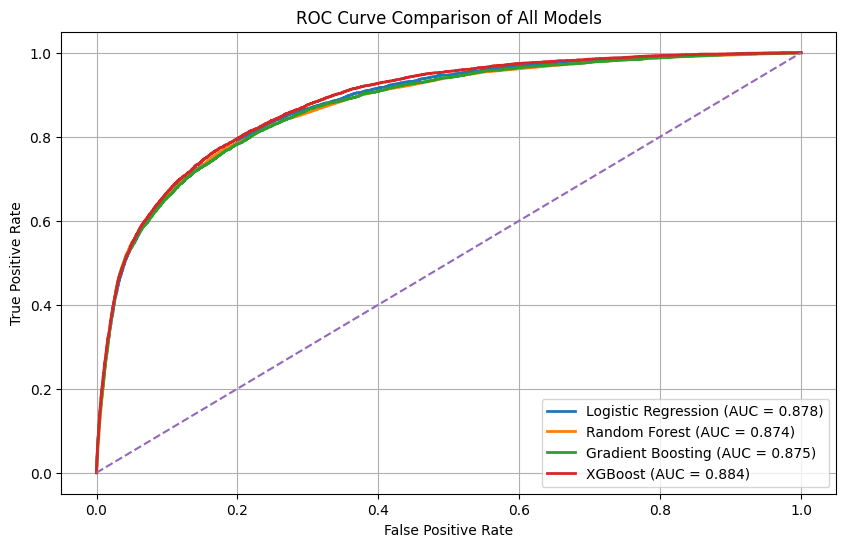

In [32]:
# 18, ROC Curve

plt.figure(figsize=(10, 6))

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

for name, model in models.items():

    probabilities = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of All Models")
plt.legend()
plt.grid(True)

plt.show()

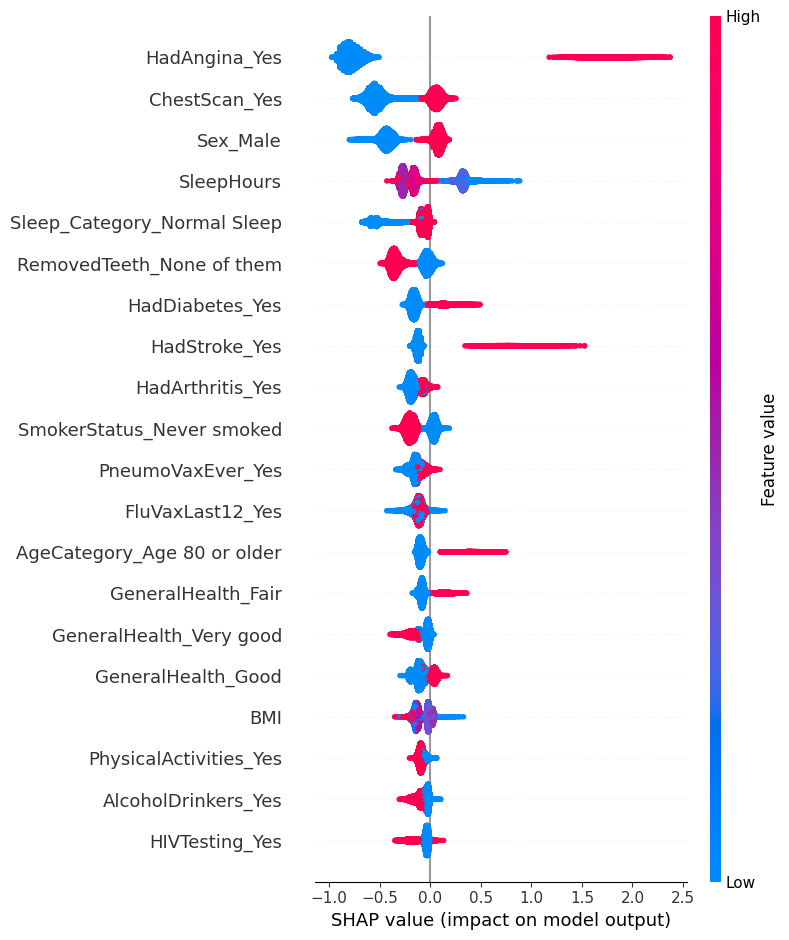

In [34]:
# SHAP Analysis
!pip install SHAP -q
import shap
import matplotlib.pyplot as plt
# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_scaled)

# Summary Plot
shap.summary_plot(
    shap_values,
    X_test_scaled,
   feature_names=X.columns
)



FINAL MODEL RECOMMENDATION
Best Model : XGBoost
Accuracy   : 0.9470
Precision  : 0.5639
Recall     : 0.2706
F1 Score   : 0.3657
ROC-AUC    : 0.8844


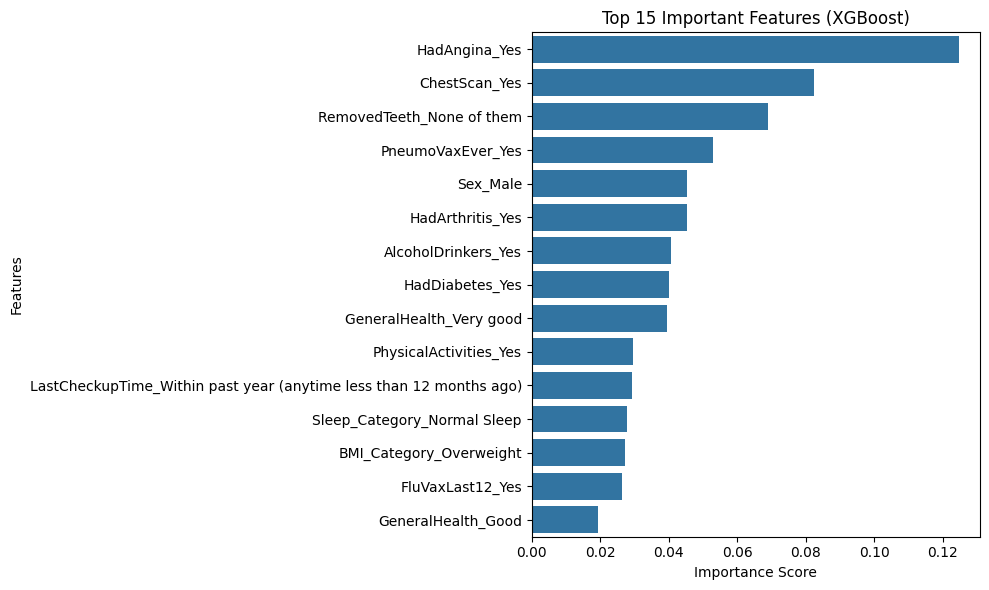

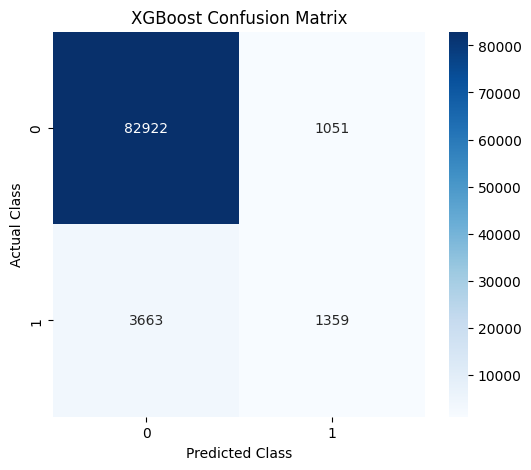

In [35]:
# 19 Model Insight

# Find best model based on ROC-AUC
best_model = comparison_df.loc[
    comparison_df["ROC-AUC"].idxmax()
]

print("=" * 60)
print("FINAL MODEL RECOMMENDATION")
print("=" * 60)

print(f"Best Model : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1 Score   : {best_model['F1 Score']:.4f}")
print(f"ROC-AUC    : {best_model['ROC-AUC']:.4f}")

# XGBoost Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

# XGBoost Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [36]:
df.to_csv('HadHeartAttack_cleaned.csv', index=False)

In [37]:
from google.colab import files
files.download('HadHeartAttack_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>